In [4]:
# Продолжайте развивать генератор данных.
# Решите задачу трекинга объектов.
# Этап 1. Генератор последовательности кадров с потоком клеток, перемещающихся "слева - направо".
#  - сгенерировать последовательность кадров в 10 секунд (итого - примерно 240 кдаров)
# - первичное положение клеток - случайный пиксель
# - при достижении границы изображения объект прекращает свое существование
# - пусть генератор пути клеток позволяет перемещать клетку по синусоиде  y(x(t) ) = ax+b + c * sin( omega *x) + eps_noise 
# - a,b,c omega - случайно сгенерированные значения для данной клетки  eps_noise - случайное значение для каждой секунды
# - a,b,c omega - случайно сгенерированные значения для данной клетки
# - 10 секунду - 10 отсчетов времени t,  положение между кажром 0 и кадром 24 интерполируется при помощи линейной интерполяции по формуле: 
# - выполнить то же самое, только зависимость не T(z),как в примере, а y(x)

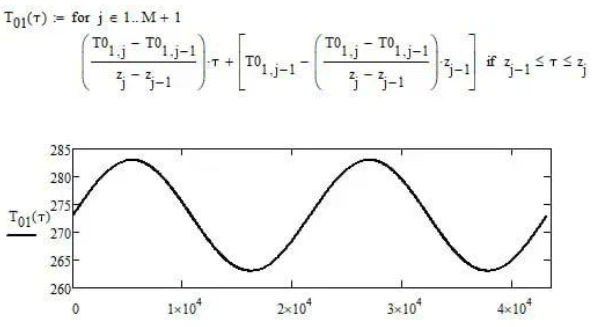

In [ ]:
# Этап 2. Трекинг объектов.
# Используя пример, приведенный в лекции про трекинг, решить задачу трекинга объектов
# Пути (положения) объктов на каждом кадре сохранить в файл.
# Визуализировать траектории объектов на изображении.

In [46]:
import numpy as np
import cv2
import random
from IPython.display import display, Video
import os
import glob
import matplotlib.pyplot as plt

class CellTrackingGenerator:
    def __init__(self, num_cells=5, video_size=(512, 512), num_frames=240, fon_path="", patch_path="", trajectory_save_path="trajectories.csv"):
        self.num_cells = num_cells
        self.video_size = video_size
        self.num_frames = num_frames
        self.fon_path = fon_path
        self.patch_path = patch_path
        self.trajectory_save_path = trajectory_save_path

        self.fon_images = glob.glob(os.path.join(fon_path, "*.png"))
        self.patch_images = glob.glob(os.path.join(patch_path, "*.png"))

        self.frame_idx = 0
        self.params = []

        self.background = cv2.imread(random.choice(self.fon_images))
        self.background = cv2.resize(self.background, self.video_size)

        self.patch = cv2.imread(random.choice(self.patch_images), cv2.IMREAD_UNCHANGED)
        if self.patch.shape[2] == 4:  
            self.patch_alpha = self.patch[:, :, 3] / 255.0
            self.patch = self.patch[:, :, :3]  
        else:
            self.patch_alpha = np.ones(self.patch.shape[:2], dtype=np.float32)

        for _ in range(num_cells):
            a = random.uniform(-1, 1)
            b = random.uniform(0, self.video_size[1])
            c = random.uniform(-10, 10)
            omega = random.uniform(0.1, 1)
            self.params.append((a, b, c, omega))

        self.positions = [(0, random.randint(0, self.video_size[1] - 1) + i * 20) for i in range(num_cells)]  # Расстояние между клетками
        self.bboxes = [] 
        self.trajectories = [[] for _ in range(num_cells)]  

    def overlay_patch_on_background(self, background, patch, alpha, x_offset, y_offset):
        patch_height, patch_width = patch.shape[:2]
        if x_offset + patch_width > background.shape[1]:
            patch_width = background.shape[1] - x_offset  
        if y_offset + patch_height > background.shape[0]:
            patch_height = background.shape[0] - y_offset  

        for c in range(3):  
            background[y_offset:y_offset + patch_height, x_offset:x_offset + patch_width, c] = \
                (1.0 - alpha[:patch_height, :patch_width]) * background[y_offset:y_offset + patch_height, x_offset:x_offset + patch_width, c] + \
                alpha[:patch_height, :patch_width] * patch[:patch_height, :patch_width, c]
        return background

    def generate_frame(self, t, with_trajectories=False):
        frame = self.background.copy()

        self.bboxes.clear()

        for idx, (x, y) in enumerate(self.positions):
            a, b, c, omega = self.params[idx]
            noise = random.uniform(-5, 5)  

            x_t = t * (self.video_size[0] - 1) / self.num_frames  
            y_t = int(a * x_t + b + c * np.sin(omega * x_t) + noise)
            y_t = np.clip(y_t, 0, self.video_size[1] - 1)  

            self.positions[idx] = (x_t, y_t)

            if x_t >= self.video_size[0]:
                continue

            self.trajectories[idx].append((x_t, y_t))

            frame = self.overlay_patch_on_background(frame, self.patch, self.patch_alpha, int(x_t), y_t)

            self.bboxes.append([x_t - 5, y_t - 5, 10, 10])

        if with_trajectories:
            for idx, trajectory in enumerate(self.trajectories):
                for i in range(1, len(trajectory)):
                    start = tuple(map(int, trajectory[i-1]))
                    end = tuple(map(int, trajectory[i]))
                    cv2.line(frame, start, end, (255, 0, 0), 2)  # Рисуем линию траектории

        return frame

    def run(self):
        frames_no_trajectories = []
        frames_with_trajectories = []
        
        for t in range(self.num_frames):
            frame_no_trajectory = self.generate_frame(t, with_trajectories=False)
            frame_with_trajectory = self.generate_frame(t, with_trajectories=True)
    
            frames_no_trajectories.append(frame_no_trajectory)
            frames_with_trajectories.append(frame_with_trajectory)
    
        # Сохранение путей объектов в файл 
        with open(self.trajectory_save_path, "w") as file:
            for idx, trajectory in enumerate(self.trajectories):
                for (x, y) in trajectory:
                    file.write(f"{idx},{x},{y}\n")
    
        return frames_no_trajectories, frames_with_trajectories

    def save_video(self, frames, output_filename="output_video.mp4"):
        fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
        out = cv2.VideoWriter(output_filename, fourcc, 30, self.video_size)
        
        for frame in frames:
            out.write(frame)  

        out.release() 


if __name__ == "__main__":
    video_size = (512, 512) 
    num_frames = 240
    fon_path = "/Users/zuhroabdulloeva/Desktop/4 КУРС/cv/blood_cells_dataset/fon/"  # Путь к фонам
    patch_path = "/Users/zuhroabdulloeva/Desktop/4 КУРС/cv/blood_cells_dataset/patch/"  # Путь к патчам

    generator = CellTrackingGenerator(num_cells=5, video_size=video_size, num_frames=num_frames, fon_path=fon_path, patch_path=patch_path)
    frames_no_trajectories, frames_with_trajectories = generator.run()

    video_filename_no_trajectories = "video_cell_tracking_no_trajectories.mp4"
    video_filename_with_trajectories = "video_cell_tracking_with_trajectories.mp4"
    
    generator.save_video(frames_no_trajectories, output_filename=video_filename_no_trajectories)
    generator.save_video(frames_with_trajectories, output_filename=video_filename_with_trajectories)

    print("Созданное видео")
    display(Video(video_filename_no_trajectories, embed=True))

    print("Видео с траекториями:")
    display(Video(video_filename_with_trajectories, embed=True))

Созданное видео


Видео с траекториями:
